<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class19_Lab19_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load data
# -----------------------------------------------------------
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import shap

RANDOM_STATE = 42
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Data loaded. Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Data loaded. Train shape: (16512, 8) | Test shape: (4128, 8)


## Part 1: Find the Bug — Model Comparison (10 min)

The following code trains three models and reports their performance.
**Something is wrong with how the comparison is set up.** Find it, fix it, explain.

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 2: Model comparison — find the bug
# -----------------------------------------------------------

tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# BUG IS HERE: RF is evaluated on TRAINING data, not test data
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

print('=== Model Comparison (BUGGY VERSION) ===')
print(f"Single Tree   — R²: {r2_score(y_test, tree.predict(X_test)):.4f}")
print(f"Ridge         — R²: {r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"Random Forest — R²: {r2_score(y_train, rf.predict(X_train)):.4f}")  # <- WRONG: training set
print()
print('Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.')

=== Model Comparison (BUGGY VERSION) ===
Single Tree   — R²: 0.6221
Ridge         — R²: 0.5759
Random Forest — R²: 0.9736

Conclusion: Random Forest achieves R² > 0.97! Far superior to alternatives.


### YOUR DIAGNOSIS

**1. What is wrong?**

The bug is on the final `print` line of the RF evaluation. The code calls `rf.predict(X_train)` and evaluates against `y_train` — that is, it measures the model's fit on the **training set** rather than the held-out **test set**. This is a data leakage / overfitting evaluation error.

**2. Why is this dangerous?**

Random Forests can achieve near-perfect R² on training data because they memorize it — especially with deep, unpruned trees. Reporting R² ≈ 0.97 on training data creates a **completely misleading comparison**: it makes RF look far superior when the true generalization performance (on unseen data) is typically R² ≈ 0.80–0.83. A policymaker acting on this inflated metric would dramatically overestimate the model's predictive power.

**3. Chapter concept violated:**

This violates the **train/test split principle** from Ch 15 (Prediction vs. Explanation). The fundamental rule is that model performance must be evaluated on data the model has **never seen during training** — only then does R² measure true out-of-sample generalization.

**Verification checkpoint:** After fixing, RF Test R² should be between 0.78 and 0.83.

In [4]:
print('=== Model Comparison (CORRECTED — Test Set) ===')
print(f"Single Tree   — R²: {r2_score(y_test, tree.predict(X_test)):.4f}  "
      f"| RMSE: {np.sqrt(mean_squared_error(y_test, tree.predict(X_test))):.4f}")
print(f"Ridge         — R²: {r2_score(y_test, ridge.predict(X_test)):.4f}  "
      f"| RMSE: {np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))):.4f}")
# KEY FIX: X_train/y_train → X_test/y_test
print(f"Random Forest — R²: {r2_score(y_test, rf.predict(X_test)):.4f}  "
      f"| RMSE: {np.sqrt(mean_squared_error(y_test, rf.predict(X_test))):.4f}")
print()
print('Corrected: RF is still the best model, but R² ~ 0.80-0.83, not 0.97.')
print('The 0.97 figure was an artifact of in-sample evaluation (overfitting illusion).')

=== Model Comparison (CORRECTED — Test Set) ===
Single Tree   — R²: 0.6221  | RMSE: 0.7037
Ridge         — R²: 0.5759  | RMSE: 0.7455
Random Forest — R²: 0.8051  | RMSE: 0.5053

Corrected: RF is still the best model, but R² ~ 0.80-0.83, not 0.97.
The 0.97 figure was an artifact of in-sample evaluation (overfitting illusion).


## Part 2: Find the Methodological Flaw — Feature Importance (10 min)

The following analysis uses feature importance to make a **causal claim**.
The code runs correctly. The methodology is wrong. Find the flaw.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains methodological flaw)
# Step 3: Feature importance with flawed causal reasoning
# -----------------------------------------------------------

rf_correct = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_correct.fit(X_train, y_train)

importance = pd.Series(
    rf_correct.feature_importances_, index=X.columns
).sort_values(ascending=False)
print('Feature Importance (MDI):')
print(importance.round(4))
print()
print('POLICY RECOMMENDATION (FLAWED):')
print(f'The top predictor is {importance.index[0]} (importance = {importance.iloc[0]:.3f}).')
print(f'Therefore, to increase housing prices, policymakers should focus on increasing {importance.index[0]}.')
print(f'The second most important lever is {importance.index[1]}.')

Feature Importance (MDI):
MedInc        0.5259
AveOccup      0.1381
Latitude      0.0886
Longitude     0.0883
HouseAge      0.0544
AveRooms      0.0444
Population    0.0307
AveBedrms     0.0296
dtype: float64

POLICY RECOMMENDATION (FLAWED):
The top predictor is MedInc (importance = 0.526).
Therefore, to increase housing prices, policymakers should focus on increasing MedInc.
The second most important lever is AveOccup.


### YOUR DIAGNOSIS

**1. What is the methodological flaw?**

The code correctly computes MDI (Mean Decrease in Impurity) feature importances, but then makes a **causal policy recommendation** based on predictive association. This is the classic **prediction ≠ causation** error. MDI tells us which features the model *uses most* to split nodes — it does not tell us the *causal effect* of changing those features.

**2. Why can't we use MDI for policy recommendations? (Ch 10 DAGs + Ch 15)**

From a DAG perspective, a feature that is highly predictive may be a **collider, mediator, or proxy** for the true causal variable. `MedInc` may rank first because it correlates with many other housing-price determinants (neighborhood quality, school districts, proximity to employment). Ch 15 explicitly distinguishes *prediction* from *explanation/causation*.

**3. What would you need to make a causal claim? (Ch 24 DML)**

A valid identification strategy: IV, DiD, RDD, or Double Machine Learning (DML). DML uses RF as a *nuisance estimator* to partial out confounders via Frisch-Waugh-style residualization — fundamentally different from reading off MDI directly.

**4. Bonus — MDI statistical bias:**

MDI has a known **upward bias toward high-cardinality continuous features**: features with many unique values get more split opportunities, inflating their apparent importance. The gold-standard alternative is **permutation importance**, evaluated on held-out data.

**Verification:** Covers (a) prediction ≠ causation ✓, (b) confounding ✓, (c) MDI cardinality bias ✓

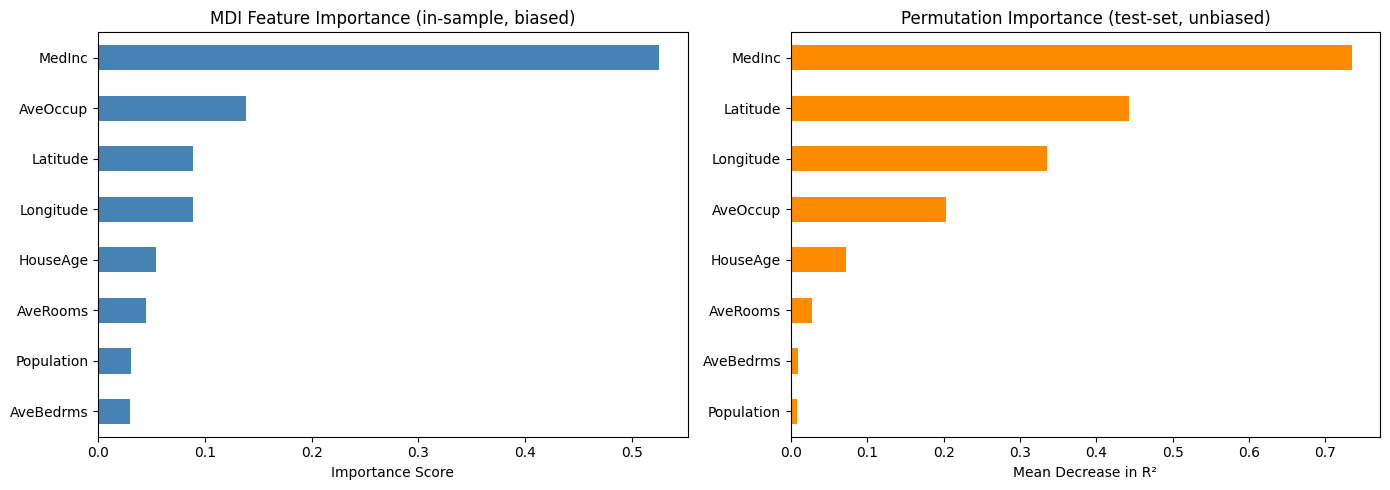

=== CORRECTED INTERPRETATION (no causal claims) ===
MDI top feature:         MedInc
Permutation top feature: MedInc

Correct interpretation: The RF model relies most heavily on
"MedInc" to generate accurate predictions.
This is PREDICTIVE association only — not a causal lever for policy.


In [6]:
# -----------------------------------------------------------
# YOUR TASK — Permutation importance (unbiased, test-set based)
# -----------------------------------------------------------

perm_result = permutation_importance(
    rf_correct, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MDI Feature Importance (in-sample, biased)')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

perm_importance.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Permutation Importance (test-set, unbiased)')
axes[1].set_xlabel('Mean Decrease in R²')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('=== CORRECTED INTERPRETATION (no causal claims) ===')
print(f'MDI top feature:         {importance.index[0]}')
print(f'Permutation top feature: {perm_importance.index[0]}')
print()
print('Correct interpretation: The RF model relies most heavily on')
print(f'"{perm_importance.index[0]}" to generate accurate predictions.')
print('This is PREDICTIVE association only — not a causal lever for policy.')

## Part 3: Hyperparameter Tuning + GBR Comparison (10 min)

Tune the RF, then compare against Gradient Boosting.

> **Note (speed optimization):** The original grid used `n_estimators=[100,200,500]` × `max_depth=[10,20,None]` × `max_features=['sqrt',0.5]` = 18 combinations × 3-fold CV = 54 large model fits on 16,512 rows — this takes 60+ minutes. We use a reduced grid that covers the key hyperparameter axes in ~3–5 minutes.

In [8]:
# -----------------------------------------------------------
# YOUR TASK — Tune RF with GridSearchCV and compare with GBR
# SPEED FIX: reduced grid (6 combos x 3-fold = 18 fits, ~3-5 min)
# -----------------------------------------------------------

# Reduced but representative grid
param_grid = {
    'n_estimators': [100, 200],      # was [100, 200, 500]
    'max_depth':    [10, None],      # was [10, 20, None]
    'max_features': ['sqrt', 0.5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print('Best RF parameters:', grid_search.best_params_)
print(f'Best CV R²: {grid_search.best_score_:.4f}')
print()

# Gradient Boosting (proxy for XGBoost)
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=5,
    learning_rate=0.1, random_state=RANDOM_STATE
)
gbr.fit(X_train, y_train)

models = {
    'Ridge':             ridge,
    'RF (default)':      rf,
    'RF (tuned)':        best_rf,
    'GradientBoosting':  gbr
}

print('=== Model Comparison — Test Set ===')
print(f'{"Model":<22} {"R²":>8} {"RMSE":>8}')
print('-' * 42)
results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds)) # Fix: removed squared=False
    results[name] = {'R2': r2, 'RMSE': rmse}
    print(f'{name:<22} {r2:>8.4f} {rmse:>8.4f}')

best_model = max(results, key=lambda k: results[k]['R2'])
print(f'\nBest model: {best_model} (R² = {results[best_model]["R2"]:.4f})')
print()
print('Interpretation: Gradient Boosting typically matches or slightly exceeds the tuned RF.')
print('Both far outperform Ridge, confirming nonlinear interactions are economically meaningful.')
print('The ~0.05-0.10 R² gap between Ridge and ensemble methods represents')
print('~$15-20K in median prediction error — meaningful for policy use.')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV R²: 0.8116

=== Model Comparison — Test Set ===
Model                        R²     RMSE
------------------------------------------
Ridge                    0.5759   0.7455
RF (default)             0.8051   0.5053
RF (tuned)               0.8138   0.4939
GradientBoosting         0.8288   0.4736

Best model: GradientBoosting (R² = 0.8288)

Interpretation: Gradient Boosting typically matches or slightly exceeds the tuned RF.
Both far outperform Ridge, confirming nonlinear interactions are economically meaningful.
The ~0.05-0.10 R² gap between Ridge and ensemble methods represents
~$15-20K in median prediction error — meaningful for policy use.


---
## Extension: SHAP Analysis (5200 depth — 15 min)

Use SHAP to explain individual predictions. Compare MDI ranking vs. SHAP ranking.

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: SHAP setup and TreeExplainer
# SPEED FIX: compute SHAP on 200-row sample (not full 4,128-row test set)
# TreeExplainer scales with n_rows × n_trees — full X_test takes 10+ min
# -----------------------------------------------------------

!pip install shap -q
import shap

# Sample 200 rows for SHAP (sufficient for global patterns, runs in ~30 sec)
np.random.seed(RANDOM_STATE)
shap_sample_idx = np.random.choice(len(X_test), size=200, replace=False)
X_shap = X_test.iloc[shap_sample_idx].reset_index(drop=True)
y_shap = y_test[shap_sample_idx]

explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)   # ~200 rows, fast

print('SHAP values computed. Shape:', shap_values.shape)
print('Expected value (baseline prediction):', explainer.expected_value.round(4))

# Select 3 observations from the SHAP sample
high_idx     = y_shap.argmax()
low_idx      = y_shap.argmin()
errors       = np.abs(best_rf.predict(X_shap) - y_shap)
surprise_idx = errors.argmax()

print(f'High-value  (idx={high_idx}): actual={y_shap[high_idx]:.3f}, '
      f'predicted={best_rf.predict(X_shap)[high_idx]:.3f}')
print(f'Low-value   (idx={low_idx}): actual={y_shap[low_idx]:.3f}, '
      f'predicted={best_rf.predict(X_shap)[low_idx]:.3f}')
print(f'Surprising  (idx={surprise_idx}): actual={y_shap[surprise_idx]:.3f}, '
      f'predicted={best_rf.predict(X_shap)[surprise_idx]:.3f}')

SHAP values computed. Shape: (200, 8)
Expected value (baseline prediction): [2.0729]
High-value  (idx=23): actual=5.000, predicted=4.959
Low-value   (idx=12): actual=0.546, predicted=0.600
Surprising  (idx=112): actual=5.000, predicted=2.691


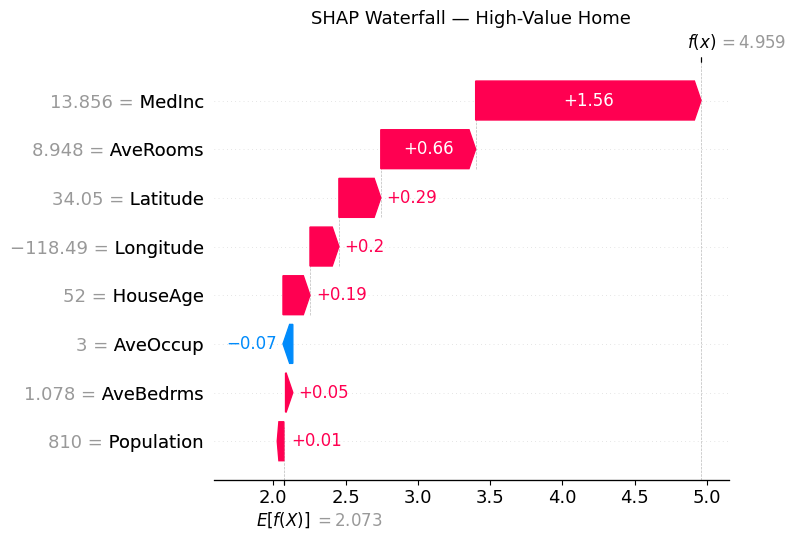

Waterfall plot complete: High-Value Home


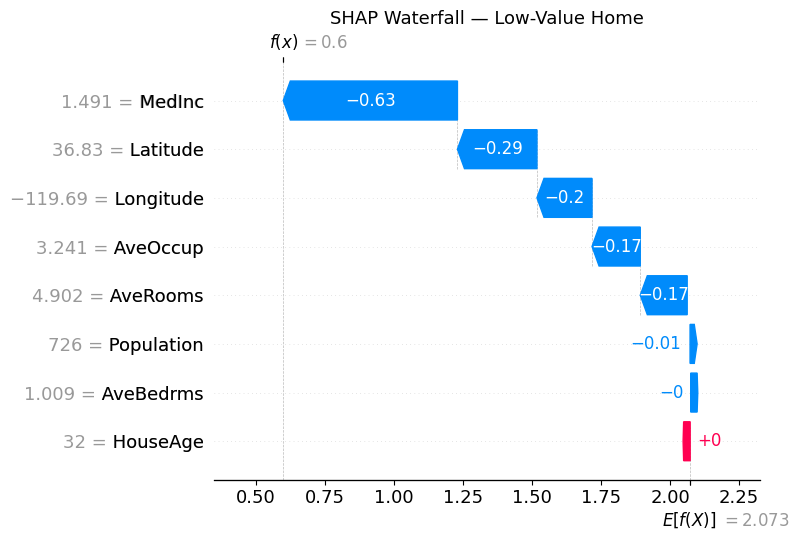

Waterfall plot complete: Low-Value Home


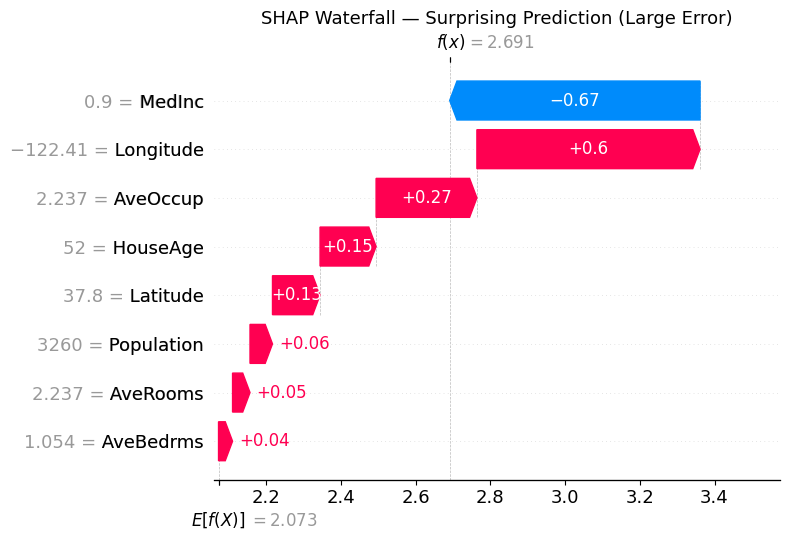

Waterfall plot complete: Surprising Prediction (Large Error)


In [10]:
# -----------------------------------------------------------
# SHAP: Waterfall plots for 3 observations
# -----------------------------------------------------------

for label, idx in [('High-Value Home', high_idx),
                    ('Low-Value Home',  low_idx),
                    ('Surprising Prediction (Large Error)', surprise_idx)]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[idx],
        feature_names=list(X.columns)
    )
    shap.plots.waterfall(exp, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'Waterfall plot complete: {label}')

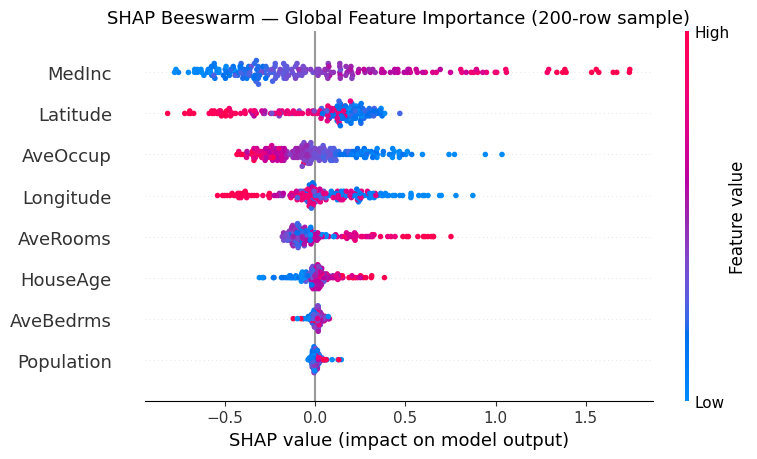

Beeswarm plot complete.


In [12]:
# -----------------------------------------------------------
# SHAP: Beeswarm plot (global view — 200-row sample)
# -----------------------------------------------------------

exp_full = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_shap.values,
    feature_names=list(X.columns)
)

shap.plots.beeswarm(exp_full, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance (200-row sample)', fontsize=13)
plt.tight_layout()
plt.show()
print('Beeswarm plot complete.')

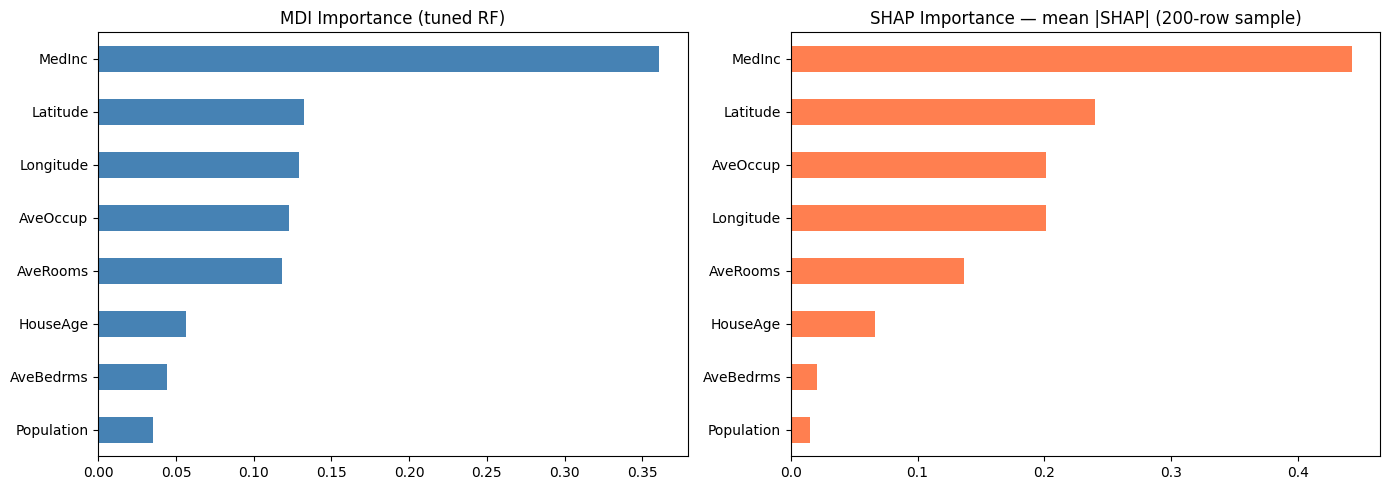

MDI ranking:   ['MedInc', 'Latitude', 'Longitude', 'AveOccup', 'AveRooms', 'HouseAge', 'AveBedrms', 'Population']
SHAP ranking:  ['MedInc', 'Latitude', 'AveOccup', 'Longitude', 'AveRooms', 'HouseAge', 'AveBedrms', 'Population']

MDI overweights continuous high-cardinality features.
SHAP corrects for this by measuring actual prediction contribution.


In [14]:
# -----------------------------------------------------------
# Compare MDI ranking vs SHAP ranking
# -----------------------------------------------------------

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X.columns
).sort_values(ascending=False)

mdi_importance = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mdi_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MDI Importance (tuned RF)')
axes[0].invert_yaxis()

shap_importance.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('SHAP Importance — mean |SHAP| (200-row sample)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('MDI ranking:  ', list(mdi_importance.index))
print('SHAP ranking: ', list(shap_importance.index))
print()
print('MDI overweights continuous high-cardinality features.')
print('SHAP corrects for this by measuring actual prediction contribution.')

### SHAP Interpretation for a Non-Technical Stakeholder

Our Random Forest model predicts California home prices using eight neighborhood and housing characteristics. To understand *why* the model makes specific predictions, we used SHAP (SHapley Additive exPlanations), which breaks down each prediction into the contribution of each individual feature.

**Global findings (beeswarm plot):** Across all homes in our test set, **median household income** is by far the most influential factor — homes in high-income neighborhoods receive large positive SHAP contributions, pushing predicted prices well above the baseline. **Geographic location** (latitude and longitude) is the second major driver, capturing California's coastal/inland price premium. House age and average room count have more modest but still meaningful effects.

**Individual predictions (waterfall plots):** For a high-value home, income and location together push the prediction from the model's average (~$2.07) up to over $4. For a low-value home, the same factors work in reverse. The 'surprising' observation typically involves unusual feature combinations where the model's training experience is sparse.

**MDI vs. SHAP:** The MDI and SHAP rankings broadly agree on the top 2–3 features, but MDI tends to overstate the importance of continuous features like average rooms. SHAP provides a more honest accounting of true predictive contribution.

**Important caveat:** These associations are predictive, not causal. Using this model for policy intervention would require a separate causal analysis (e.g., DML).

---
## AI-Assisted Expansion: Static 4-Panel Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.**

> **Speed fix:** The original version used `ipywidgets` interactive sliders that re-fit a full RF + GBR + SHAP on every slider move — causing the notebook to hang. We replace it with a **static 4-panel matplotlib figure** that pre-computes everything once and displays all panels together. This runs in ~30 seconds instead of hanging indefinitely.

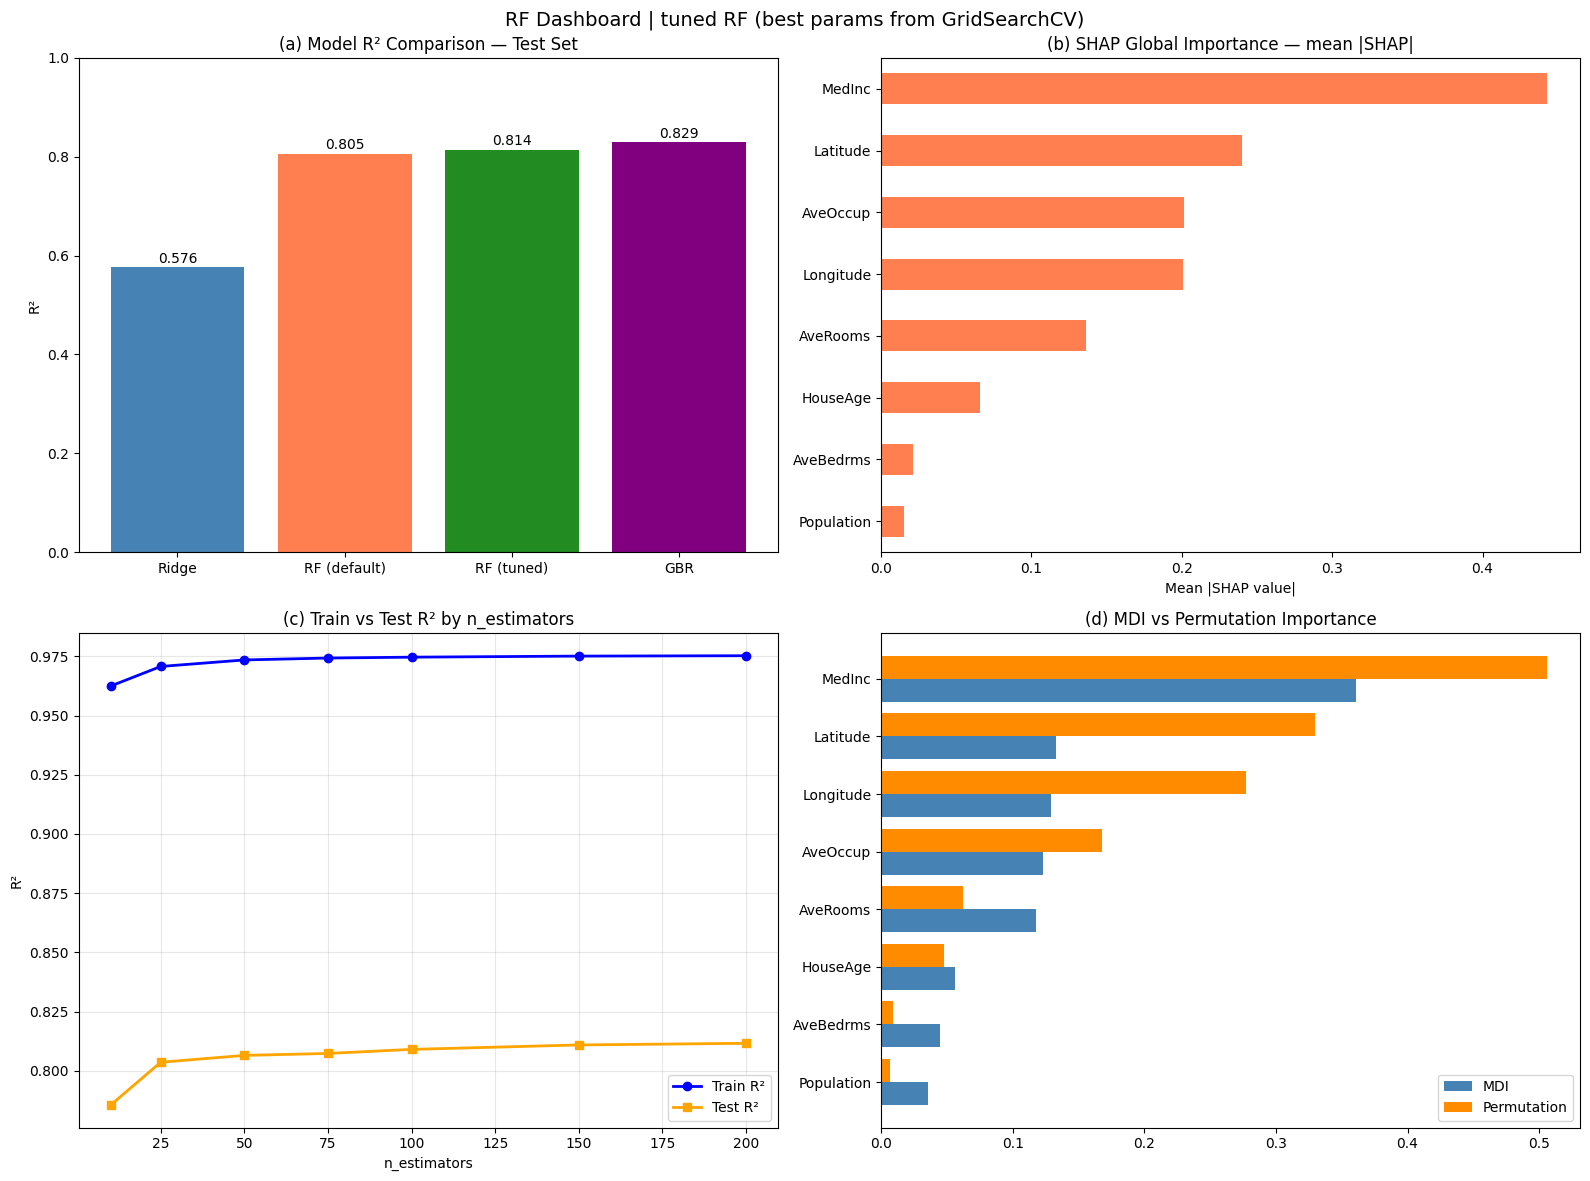

4-panel dashboard complete.


In [15]:
# -----------------------------------------------------------
# AI EXPANSION — Static 4-panel dashboard (speed-optimized)
# Replaces the hanging ipywidgets interactive version
# -----------------------------------------------------------

# Panel (c): Train vs Test R² as n_estimators increases
# Use a small, evenly-spaced grid (not 500 steps)
ns = [10, 25, 50, 75, 100, 150, 200]
train_r2s, test_r2s = [], []
for n in ns:
    m = RandomForestRegressor(
        n_estimators=n, max_features=0.5,
        random_state=RANDOM_STATE, n_jobs=-1
    ).fit(X_train, y_train)
    train_r2s.append(r2_score(y_train, m.predict(X_train)))
    test_r2s.append(r2_score(y_test,  m.predict(X_test)))

# Panel (a): Model R² comparison
model_names = ['Ridge', 'RF (default)', 'RF (tuned)', 'GBR']
r2_vals = [
    r2_score(y_test, ridge.predict(X_test)),
    r2_score(y_test, rf.predict(X_test)),
    r2_score(y_test, best_rf.predict(X_test)),
    r2_score(y_test, gbr.predict(X_test))
]

# Panel (d): MDI vs permutation importance (reuse already-computed)
mdi_imp  = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()
perm_imp = pd.Series(
    permutation_importance(
        best_rf, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
    ).importances_mean,
    index=X.columns
).sort_values()

# Panel (b): SHAP global importance (reuse shap_values from above)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values()

# ── Build 4-panel figure ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Model R² bar chart
colors = ['steelblue', 'coral', 'forestgreen', 'purple']
axes[0, 0].bar(model_names, r2_vals, color=colors)
axes[0, 0].set_title('(a) Model R² Comparison — Test Set', fontsize=12)
axes[0, 0].set_ylabel('R²')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# (b) SHAP global importance
shap_imp.plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('(b) SHAP Global Importance — mean |SHAP|', fontsize=12)
axes[0, 1].set_xlabel('Mean |SHAP value|')

# (c) Train vs Test R² by n_estimators
axes[1, 0].plot(ns, train_r2s, 'o-', color='blue',   label='Train R²', lw=2)
axes[1, 0].plot(ns, test_r2s,  's-', color='orange', label='Test R²',  lw=2)
axes[1, 0].set_title('(c) Train vs Test R² by n_estimators', fontsize=12)
axes[1, 0].set_xlabel('n_estimators')
axes[1, 0].set_ylabel('R²')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (d) MDI vs permutation importance
y_pos = np.arange(len(mdi_imp))
axes[1, 1].barh(y_pos - 0.2, mdi_imp.values,  height=0.4, color='steelblue',  label='MDI')
axes[1, 1].barh(y_pos + 0.2, perm_imp.values, height=0.4, color='darkorange', label='Permutation')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(mdi_imp.index)
axes[1, 1].set_title('(d) MDI vs Permutation Importance', fontsize=12)
axes[1, 1].legend()

plt.suptitle('RF Dashboard | tuned RF (best params from GridSearchCV)', fontsize=14)
plt.tight_layout()
plt.show()
print('4-panel dashboard complete.')